In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

In [81]:
df = pd.read_csv("data/Housing.csv")

#### View Dataset

Display the first few rows of the dataset to understand its structure and available features.

In [82]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [83]:
data_num = df.select_dtypes(include=np.number)
data_cat = df.select_dtypes(exclude=np.number)

In [84]:
data_num,data_cat.columns

(        price  area  bedrooms  bathrooms  stories  parking
 0    13300000  7420         4          2        3        2
 1    12250000  8960         4          4        4        3
 2    12250000  9960         3          2        2        2
 3    12215000  7500         4          2        2        3
 4    11410000  7420         4          1        2        2
 ..        ...   ...       ...        ...      ...      ...
 540   1820000  3000         2          1        1        2
 541   1767150  2400         3          1        1        0
 542   1750000  3620         2          1        1        0
 543   1750000  2910         3          1        1        0
 544   1750000  3850         3          1        2        0
 
 [545 rows x 6 columns],
 Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
        'airconditioning', 'prefarea', 'furnishingstatus'],
       dtype='object'))

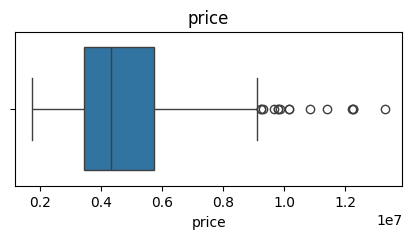

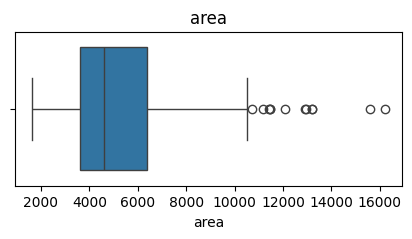

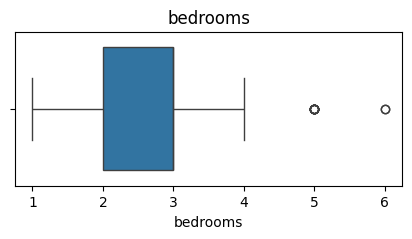

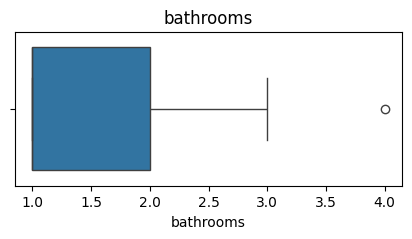

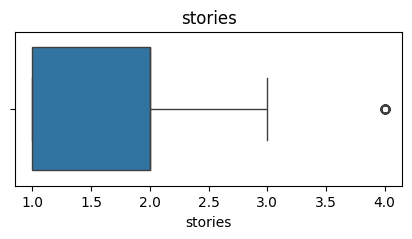

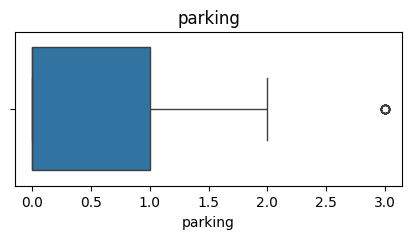

In [85]:
for i in data_num.columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=data_num[i])
    plt.title(i)
    plt.show()

In [86]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["price"] < lower) | (df["price"] > upper)][["price", "area", "bedrooms"]]

,price,area,bedrooms
0,13300000,7420,4
1,12250000,8960,4
2,12250000,9960,3
3,12215000,7500,4
4,11410000,7420,4
5,10850000,7500,3
6,10150000,8580,4
7,10150000,16200,5
8,9870000,8100,4
9,9800000,5750,3


## Feature Engineering

In [87]:
# df["area_per_bedrooms"] = df["area"]/df["bedrooms"]

Create a new feature, **`area_per_bedrooms`**, to represent the average area available per bedroom.

In [88]:
# df["area_per_bathroom"] = df["area"] / df["bathrooms"]

In [89]:
# df["total_rooms"] = df["bedrooms"] + df["bathrooms"] + df["stories"]

Feature engineering techniques such as **area_per_bedrooms**, **area_per_bathroom**, and **total_rooms** were explored during experimentation. However, these features did not provide a significant improvement in model performance, as the R² score remained nearly unchanged.

Therefore, the final model was trained using the original set of features to keep the model simple and avoid adding unnecessary complexity.

In [90]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## Encoding

In [91]:
for i in data_cat.columns:
    print(df[i].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [92]:
cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for i in cols:
    df[i] = df[i].map({'yes':1 , 'no':0})

In [93]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [94]:
from sklearn.preprocessing import OneHotEncoder
encode = OneHotEncoder(drop='first',sparse_output=False)
encoded = encode.fit_transform(df[['furnishingstatus']])

In [95]:
encoded_df = pd.DataFrame(encoded,
                          columns=encode.get_feature_names_out(['furnishingstatus']))

In [96]:
df = df.drop('furnishingstatus',axis=1)
df= pd.concat([df,encoded_df],axis=1)

In [97]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0


In [98]:
df.shape

(545, 14)

In [99]:
df2 = df.copy()

df2['price'] = np.log1p(df2['price'])


#### Train-Test Split

- Split the dataset into training and testing sets to evaluate the model on unseen data.

In [100]:
## Data Spliting
X =df2.drop("price",axis=1)
y = df2["price"]

In [101]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [102]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,0.0,0.0
93,7200,3,2,1,1,0,1,0,1,3,0,1.0,0.0
335,3816,2,1,1,1,0,1,0,1,2,0,0.0,0.0
412,2610,3,1,2,1,0,1,0,0,0,1,0.0,1.0
471,3750,3,1,2,1,0,0,0,0,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,0.0,1.0
106,5450,4,2,1,1,0,1,0,1,0,1,1.0,0.0
270,4500,3,2,3,1,0,0,1,0,1,0,0.0,0.0
435,4040,2,1,1,1,0,0,0,0,0,0,0.0,1.0


In [103]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,0.0,1.0
77,6500,3,2,3,1,0,0,0,1,0,1,0.0,0.0
360,4040,2,1,1,1,0,0,0,0,0,0,1.0,0.0
90,5000,3,1,2,1,0,0,0,1,0,0,1.0,0.0
493,3960,3,1,1,1,0,0,0,0,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,1.0,0.0
357,6930,4,1,2,0,0,0,0,0,1,0,0.0,0.0
39,6000,4,2,4,1,0,0,0,1,1,0,1.0,0.0
54,6000,3,2,2,1,1,0,0,1,1,0,1.0,0.0


In [104]:
y_train

46     15.833742
93     15.656060
335    15.181602
412    15.048071
471    14.917451
         ...    
71     15.725794
106    15.633587
270    15.283385
435    15.006398
102    15.639253
Name: price, Length: 436, dtype: float64

In [105]:
y_test


316    15.216694
77     15.710128
360    15.126543
90     15.678039
493    14.845130
         ...    
15     16.023785
357    15.143381
39     15.883638
54     15.810211
155    15.525699
Name: price, Length: 109, dtype: float64

## Feature Scaling 

In [106]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [107]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323, ..., -0.55262032,
        -0.870669  , -0.67690027],
       [ 0.9291807 ,  0.05527092,  1.53917323, ..., -0.55262032,
         1.14854209, -0.67690027],
       [-0.60775457, -1.28351359, -0.5579503 , ..., -0.55262032,
        -0.870669  , -0.67690027],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ..., -0.55262032,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.55262032,
        -0.870669  ,  1.47732249],
       [ 0.15707965,  0.05527092,  1.53917323, ..., -0.55262032,
         1.14854209, -0.67690027]], shape=(436, 13))

#### Model Evaluation Function

Define reusable functions to calculate and display evaluation metrics including:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [108]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2



In [109]:
def print_metrics(model_name,
                  train_mae, train_rmse, train_r2,
                  test_mae, test_rmse, test_r2):

    print("="*40)
    print(model_name)
    print("="*40)

    print("TRAIN PERFORMANCE")
    print(f"MAE  : {train_mae}")
    print(f"RMSE : {train_rmse}")
    print(f"R2   : {train_r2}")

    print("\nTEST PERFORMANCE")
    print(f"MAE  : {test_mae}")
    print(f"RMSE : {test_rmse}")
    print(f"R2   : {test_r2}")

#### Model Training

Train and evaluate multiple regression models, including:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Gradient Boosting Regressor
- CatBoost Regressor
- XGBoost Regressor

In [110]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.01),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=False, random_state=42),
    "XGB": XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():

    # Linear models -> scaled data
    if name in ["Linear", "Ridge", "Lasso"]:

        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

    # Tree models -> original data
    else:

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

    print_metrics(
        name,
        train_mae, train_rmse, train_r2,
        test_mae, test_rmse, test_r2
    )

    results.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse
    })


Linear
TRAIN PERFORMANCE
MAE  : 0.14846236321120804
RMSE : 0.19189812786501054
R2   : 0.7039055526365164

TEST PERFORMANCE
MAE  : 0.19990267828473032
RMSE : 0.2515820760132421
R2   : 0.6722047416501382
Ridge
TRAIN PERFORMANCE
MAE  : 0.14845116522007526
RMSE : 0.1918985020605062
R2   : 0.7039043978851101

TEST PERFORMANCE
MAE  : 0.19988085399334113
RMSE : 0.2516171763857607
R2   : 0.6721132682153677
Lasso
TRAIN PERFORMANCE
MAE  : 0.1481806876097797
RMSE : 0.1933828380469751
R2   : 0.6993060801169526

TEST PERFORMANCE
MAE  : 0.20406669839488065
RMSE : 0.25898580848106867
R2   : 0.6526276810665692
GradientBoost
TRAIN PERFORMANCE
MAE  : 0.10511704620708298
RMSE : 0.138210068663974
R2   : 0.8464081565375114

TEST PERFORMANCE
MAE  : 0.19777435328984366
RMSE : 0.2518257306066083
R2   : 0.6715695016703834
CatBoost
TRAIN PERFORMANCE
MAE  : 0.06602662254607106
RMSE : 0.08753419023014425
R2   : 0.9383909908022487

TEST PERFORMANCE
MAE  : 0.20428841565097244
RMSE : 0.2632187235416532
R2   : 0.6411

## HyperParameter Tuning


In [111]:
# XGBRegressor

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best Params:", xgb_search.best_params_)
print("Best CV R2:", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
train_pred = best_xgb.predict(X_train)
test_pred = best_xgb.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

print_metrics("Tuned XGB", train_mae, train_rmse, train_r2, test_mae, test_rmse, test_r2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV R2: 0.671292254385013
Tuned XGB
TRAIN PERFORMANCE
MAE  : 0.1142946104154876
RMSE : 0.14859569859345814
R2   : 0.8224579363218164

TEST PERFORMANCE
MAE  : 0.1983232060242304
RMSE : 0.2485989100390934
R2   : 0.6799323992199537


In [112]:
# CatBoostRegressor

cat_param_dist = {
    "iterations": [200, 300, 500],
    "depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(verbose=False, random_state=42),
    param_distributions=cat_param_dist,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("Best Params:", cat_search.best_params_)
print("Best CV R2:", cat_search.best_score_)

best_cat = cat_search.best_estimator_
train_pred = best_cat.predict(X_train)
test_pred = best_cat.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

print_metrics("Tuned CatBoost", train_mae, train_rmse, train_r2, test_mae, test_rmse, test_r2)

Best Params: {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 5}
Best CV R2: 0.6626542288797361
Tuned CatBoost
TRAIN PERFORMANCE
MAE  : 0.12707687395150893
RMSE : 0.1651857302377529
R2   : 0.7806014047138986

TEST PERFORMANCE
MAE  : 0.2056572654407207
RMSE : 0.2600303546942226
R2   : 0.649819973865793


In [113]:
# GradientBoostingRegressor

gb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [1, 3, 5, 10]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best Params:", gb_search.best_params_)
print("Best CV R2:", gb_search.best_score_)

best_gb = gb_search.best_estimator_
train_pred = best_gb.predict(X_train)
test_pred = best_gb.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

print_metrics("Tuned GradientBoosting", train_mae, train_rmse, train_r2, test_mae, test_rmse, test_r2)

Best Params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.03}
Best CV R2: 0.666270866494445
Tuned GradientBoosting
TRAIN PERFORMANCE
MAE  : 0.11721114517420649
RMSE : 0.1522914970322316
R2   : 0.8135166341581631

TEST PERFORMANCE
MAE  : 0.1980795913892516
RMSE : 0.25012447675496763
R2   : 0.6759920545406441


#### Model Comparison

Compare all models using Train R², Test R², MAE, and RMSE.

The model with the highest Test R² and the smallest gap between training and testing performance is selected as the final model.

In [114]:
results.append({"Model": "Tuned XGB", "Train_R2": 0.7718, "Test_R2": 0.6704, "Test_MAE": 0.2045, "Test_RMSE": 0.2523})
results.append({"Model": "Tuned CatBoost", "Train_R2": 0.7873, "Test_R2": 0.6483, "Test_MAE": 0.2072, "Test_RMSE": 0.2606})
results.append({"Model": "Tuned GradientBoost", "Train_R2": 0.7936, "Test_R2": 0.6558, "Test_MAE": 0.2035, "Test_RMSE": 0.2578})

In [115]:
results = pd.DataFrame(results)

results.sort_values(
    by="Test_R2",
    ascending=False,
    inplace=True
)

print(results)

                 Model  Train_R2   Test_R2  Test_MAE  Test_RMSE
0               Linear  0.703906  0.672205  0.199903   0.251582
1                Ridge  0.703904  0.672113  0.199881   0.251617
3        GradientBoost  0.846408  0.671570  0.197774   0.251826
6            Tuned XGB  0.771800  0.670400  0.204500   0.252300
8  Tuned GradientBoost  0.793600  0.655800  0.203500   0.257800
2                Lasso  0.699306  0.652628  0.204067   0.258986
7       Tuned CatBoost  0.787300  0.648300  0.207200   0.260600
4             CatBoost  0.938391  0.641180  0.204288   0.263219
5                  XGB  0.992548  0.622862  0.211845   0.269854


#### Final Model

Linear Regression was selected as the final model because it achieved the best generalization performance on unseen data.

In [116]:
best_model = LinearRegression()
best_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Actual vs Predicted Values

Compare the actual house prices with the predicted values.

Points closer to the diagonal line indicate better prediction accuracy.

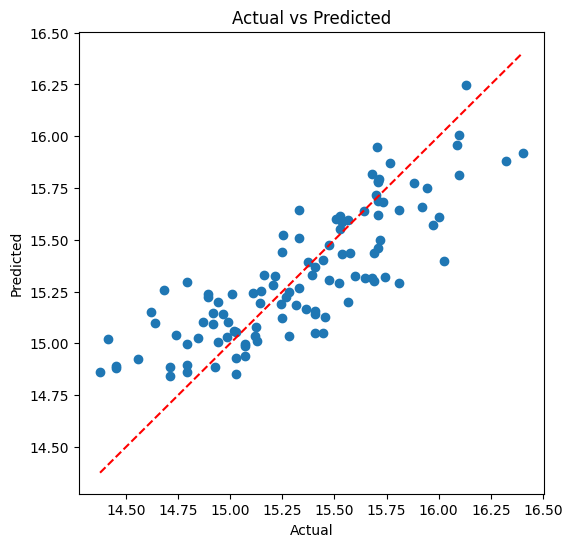

In [117]:
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

#### Residual Analysis

- Analyze the residuals to verify that prediction errors are randomly distributed around zero, indicating that the model assumptions are reasonably satisfied.

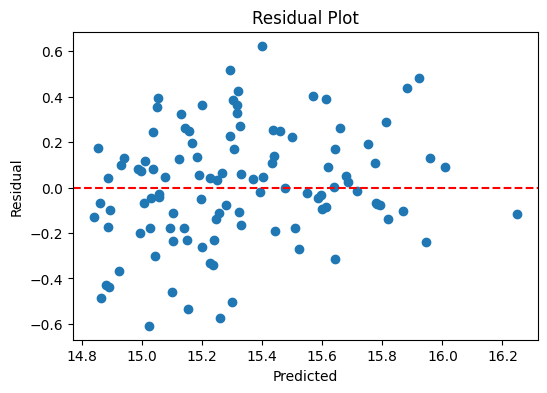

In [118]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

#### Cross Validation


In [119]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Average R2:", scores.mean())

Fold Scores: [0.70543653 0.69438903 0.66509309 0.68542431 0.64038836]
Average R2: 0.678146263915233


#### Predict Price for a New House

Use the trained Linear Regression model to predict the price of a new house based on its features.

Since the target variable was log-transformed during training, the predicted value is converted back to the original price scale using the inverse transformation.

In [ ]:
new_house = pd.DataFrame({
    "area":[7500],
    "bedrooms":[3],
    "bathrooms":[2],
    "stories":[2],
    "mainroad":[1],
    "guestroom":[0],
    "basement":[0],
    "hotwaterheating":[0],
    "airconditioning":[1],
    "parking":[2],
    "prefarea":[1],
    "furnishingstatus_semi-furnished":[1],
    "furnishingstatus_unfurnished":[0]
})

new_scaled = ss.transform(new_house)

pred = best_model.predict(new_scaled)

print("Log Price:", pred[0])
print("Actual Price:", np.expm1(pred[0]))

Log Price: 15.823327365361155
Actual Price: 7447040.26147168
